In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
from heatextremes.metrics import coverage, mean_in_time_batches, probability_of_exceedance_brier_score
import heatextremes as he 
from dask.diagnostics import ProgressBar 
from dask.distributed import Client
from pathlib import Path 
import pandas as pd 

import warnings
from zarr.errors import ZarrUserWarning



In [ ]:
era5 = he.open_cached_era5(chunks = {"time": 36, "latitude": 360, "longitude": 720})

british_isles_era5 = era5['2m_temperature'].sel(
    latitude=slice(49,61), 
    longitude=slice(-11, 3),
).resample(time="1D").mean()

if not Path("/net/monsoon/kylehall/era5_t2m_climo_daily.zarr").is_dir(): 
    print('rewriting climo')
    climo = (
        british_isles_era5
        .groupby("time.day_of_year")
        .mean()
        .to_dataset(name="t2m_daily_mean")
    )

    with ProgressBar():
        climo.to_zarr(
            "/net/monsoon/kylehall/era5_t2m_climo_daily.zarr",
            mode="w",
            zarr_format=2,
            consolidated=True,
        )
 
climo = xr.open_dataset("/net/monsoon/kylehall/era5_t2m_climo_daily.zarr", chunks={}, consolidated=True)

/home/kylehall/heat-extremes/heatextremes/open_cached_era5.py:64: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 36. This could degrade performance. Instead, consider rechunking after loading.
  xr.open_zarr(path, consolidated=True, chunks=dask_chunks)
/home/kylehall/heat-extremes/heatextremes/open_cached_era5.py:64: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 36. This could degrade performance. Instead, consider rechunking after loading.
  xr.open_zarr(path, consolidated=True, chunks=dask_chunks)
/home/kylehall/heat-extremes/heatextremes/open_cached_era5.py:64: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 36. This could degrade performance. Instead, consider rechunking after loading.
  xr.open_zarr(path, consolidated=True, chunks=dask_chunks)
/home/kylehall/heat-extremes/heatextremes/open_cached_era5.py:64: UserWarnin

In [ ]:
with ProgressBar(): 
    british_isles_era5_anomaly_2026 = (british_isles_era5.sel(time=slice(pd.Timestamp(2026, 5, 15), None)).groupby("time.day_of_year") - climo).compute()


[########################################] | 100% Completed | 6.61 ss


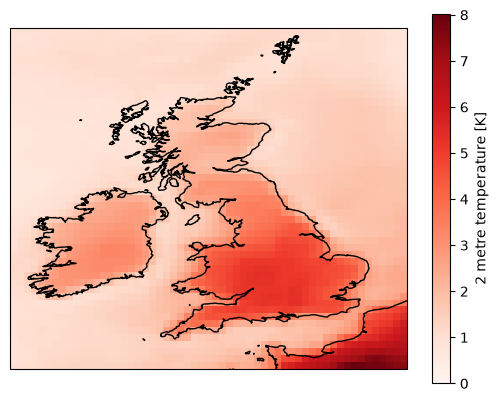

In [ ]:

pl = british_isles_era5_anomaly_2026['t2m_daily_mean'].sel(time=slice("2026-6-15", "2026-6-28")).mean('time').plot(
    subplot_kws={"projection": ccrs.PlateCarree()},
    transform=ccrs.PlateCarree(),
    cmap="Reds",
    vmin=0
)

pl.axes.coastlines()

In [ ]:
with ProgressBar():
    british_isles_aifs = xr.open_mfdataset(
        "/net/monsoon/operational/monsoon-onset/AIFS/output/raw/AIFS_ENS_v2/*.zarr", 
        chunks={
            'time': 1, 
            'lat': 90,
            'lon': 180,
            'number': -1
        }, 
        preprocess = lambda x: x[['2t']].sel(
                            lat=slice(61, 49),
                        ).sel(
                            prediction_timedelta=slice(None, None) # put in forecast day limit here
                        ).resample(prediction_timedelta="1D").mean(),
        consolidated=True
    )

    british_isles_aifs = british_isles_aifs.where(
        (british_isles_aifs.lon >= 349) | (british_isles_aifs.lon <= 3),
        drop=True,
    ).rename({'lat': 'latitude', 'lon': 'longitude'})

def match_latlon(
    da: xr.DataArray,
    reference: xr.DataArray,
    lat: str = "latitude",
    lon: str = "longitude",
) -> xr.DataArray:
    """Match latitude order and longitude convention to a reference array."""

    # Match longitude convention.
    if reference[lon].min() < 0:
        new_lon = ((da[lon] + 180) % 360) - 180
    else:
        new_lon = da[lon] % 360

    da = da.assign_coords({lon: new_lon})

    # Match coordinate ordering.
    lat_ascending = bool(reference[lat][0] < reference[lat][-1])
    lon_ascending = bool(reference[lon][0] < reference[lon][-1])

    da = da.sortby(lat, ascending=lat_ascending)
    da = da.sortby(lon, ascending=lon_ascending)

    # Put coordinates in exactly the same order as the reference.
    return da.reindex({
        lat: reference[lat],
        lon: reference[lon],
    })
british_isles_aifs = match_latlon(british_isles_aifs, british_isles_era5)

xr.testing.assert_equal(british_isles_aifs.latitude, british_isles_era5.latitude)
xr.testing.assert_equal(british_isles_aifs.longitude, british_isles_era5.longitude)

/tmp/ipykernel_3431383/501699731.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  british_isles_aifs = xr.open_mfdataset(
/tmp/ipykernel_3431383/501699731.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  british_isles_aifs = xr.open_mfdataset(
/tmp/ipykernel_3431383/501699731.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  british_isles_aifs = xr.open_mfdataset(
/tmp/ipykernel_3431383/501699731.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 180. This could degrade performance. Instead, consider rechunking after l

In [ ]:
t2m_pctls = xr.open_dataset('/net/monsoon/aasch/percentiles/percentiles_1979-2018_2m_temperature_min.nc')['2m_temperature']
t2m_pctls = t2m_pctls.sel( latitude=slice(61, 49) ).where(
        (t2m_pctls.longitude >= 349) | (t2m_pctls.longitude <= 3),
        drop=True,
    )
t2m_pctls =  match_latlon(t2m_pctls, british_isles_era5)


<xarray.DataArray '2m_temperature' (time: 64, latitude: 49, longitude: 57,
                                    quantile: 3)> Size: 4MB
array([[[[286.24786224, 286.96736969, 287.30432669],
         [286.24114227, 286.93529266, 287.25071921],
         [286.2366394 , 286.89681122, 287.18185947],
         ...,
         [286.57049408, 287.73942627, 287.98399512],
         [286.23728027, 287.76743469, 287.94985443],
         [286.13712921, 287.63330505, 287.74871259]],

        [[286.14669647, 286.83608704, 287.15304535],
         [286.12599792, 286.87840912, 287.18166721],
         [286.11018219, 286.86010742, 287.13432617],
         ...,
         [286.19510956, 287.61446533, 287.87454468],
         [286.11354218, 287.65743927, 287.8649993 ],
         [286.21432953, 287.5509964 , 287.68815933]],

        [[286.10386658, 286.72140747, 287.05055566],
         [286.04689026, 286.76535645, 287.08584961],
         [286.0073761 , 286.77727051, 287.07891113],
         ...,
...
         [287.88152771, 288.97881775, 289.53250397],
         [287.82549591, 289.0145108 , 289.59196622],
         [287.75897217, 289.06334351, 289.65274243]],

        [[285.15931396, 286.44476379, 286.96408698],
         [285.11858215, 286.40336731, 286.9155351 ],
         [285.10628967, 286.37213989, 286.86967554],
         ...,
         [287.50276947, 288.74771973, 289.31702356],
         [287.40934753, 288.79407135, 289.38249551],
         [287.48050232, 288.87656433, 289.51568683]],

        [[285.11461029, 286.43237946, 286.95790469],
         [285.07965546, 286.39293884, 286.90133612],
         [285.07989655, 286.38822357, 286.88279208],
         ...,
         [287.19681244, 288.52930573, 289.12582791],
         [287.24189301, 288.59941315, 289.19859183],
         [287.2891983 , 288.68183685, 289.32521188]]]],
      shape=(64, 49, 57, 3))
Coordinates:
  * time         (time) datetime64[ns] 512B 2026-05-15 2026-05-16 ... 2026-07-17
    dayofyear    (time) int64 512B 135 136 137 138 139 ... 194 195 196 197 198
    day_of_year  (time) int64 512B 135 136 137 138 139 ... 194 195 196 197 198
  * latitude     (latitude) float32 196B 49.0 49.25 49.5 ... 60.5 60.75 61.0
  * longitude    (longitude) float32 228B -11.0 -10.75 -10.5 ... 2.5 2.75 3.0
  * quantile     (quantile) float64 24B 0.95 0.99 0.999
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K

2026-05-23 00:00:00
[########################################] | 100% Completed | 12.23 ss


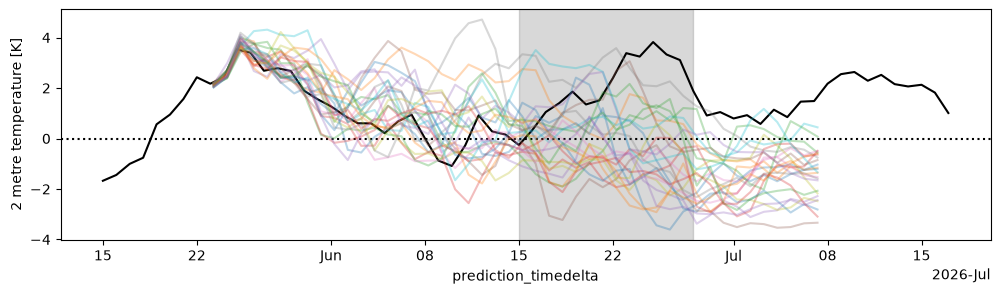

: 

In [ ]:
initializations = [pd.Timestamp(2026,5,23)] #, pd.Timestamp(2026,6, 23)]

p = british_isles_era5_anomaly_2026['t2m_daily_mean'].mean(['latitude', 'longitude']).plot.line(color='black', x='time', figsize=(12,3))
p[0].axes.axhline(0, color='black', linestyle=':')

for init in initializations:
    print(init)
    with ProgressBar():
        fcst = british_isles_aifs['2t'].sel(time=init, drop=True)
        fcst = fcst.assign_coords(prediction_timedelta = init + fcst.prediction_timedelta.values )
        fcst_anomaly = fcst.groupby('prediction_timedelta.day_of_year') - climo['t2m_daily_mean']
        fcst_anomaly.mean(['latitude', 'longitude']).plot.line(ax = p[0].axes, hue='number', x='prediction_timedelta', alpha=0.3, add_legend=False)

p[0].axes.axvspan(
    "2026-06-15",
    "2026-06-28",
    color="gray",
    alpha=0.3,
    zorder=0,
)
(t2m_pctls.sel(
    dayofyear = british_isles_era5_anomaly_2026.time.dt.day_of_year, 
    quantile=0.95
) - climo) .mean(['latitude', 'longitude']).plot.line(ax=p[0].axes, color='black', linestyle=':')




In [ ]:
t2m_pctls


<xarray.Dataset> Size: 9GB
Dimensions:         (dayofyear: 366, latitude: 721, longitude: 1440, quantile: 3)
Coordinates:
  * dayofyear       (dayofyear) int64 3kB 1 2 3 4 5 6 ... 362 363 364 365 366
  * latitude        (latitude) float32 3kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float32 6kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
  * quantile        (quantile) float64 24B 0.95 0.99 0.999
Data variables:
    2m_temperature  (dayofyear, latitude, longitude, quantile) float64 9GB ...